# Magnetic Fusion Edge Demo

In this demo ...

To get started, let's import the required libraries.

In [3]:
# third party imports
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
from scipy.optimize import fsolve

#twinLab Imports
import twinlab as tl

#set digiLab colors
colors = ["#162448","#009FE3","#7DB928","#FFB500"]


          ====== TwinLab Client Initialisation ======
          Version     : 2.17.0
          User        : dan.greenhouse@digilab.co.uk
          Server      : https://twinlab.digilab.co.uk/v3
          Environment : /Users/danielgreenhouse/Documents/Magnetic-Fusion-Performance/.env



## Set your API Key.

If you don't already have one, please vist https://www.digilab.co.uk/contact. For security, we normally recommend performing this step with a .env file or secrets.

In [4]:
tl.set_user("dan.greenhouse@digilab.co.uk")
tl.set_api_key("tl_zsmry3DwI8vKZ19ggxaN9g")

# Remove this
tl.set_server_url("https://r8py43zvu1.execute-api.eu-west-2.amazonaws.com/stage")

We need to define our edge model

In [ ]:

from edge_demo_helper import ion_flux_model

This is our sputtering model. It contains parameters upstream temperature and upstream density. It returns the sputtering yield. It has additional hyperparameters which can provide improved model complexity. 

Let's start making some data with it

In [ ]:
upstream_q_range = (1.e4, 1.e10)
num = 50

df_simple_model_train = pd.DataFrame(
    {
        "upstream q": log_space(*upstream_q_range, num),
    }
)

# Let's use our model to predict the ion flux

display(df_simple_model_train)
df['C'] = df.apply(ion_flux_model, axis=1)


(50,)


,upstream q,upstream density,connection length,target density,target temp,ion flux,sputtering rate,sputtering yield
0,1.000000e+10,1.000000e+19,5000.0,5.000013e+18,2549.601601,2.472887e+24,4.985951e+27,2016.247081
1,7.543120e+09,1.000000e+19,5000.0,5.000019e+18,2112.707286,2.251066e+24,4.371248e+27,1941.856586
2,5.689866e+09,1.000000e+19,5000.0,5.000027e+18,1750.677627,2.049144e+24,3.832330e+27,1870.210633
3,4.291934e+09,1.000000e+19,5000.0,5.000040e+18,1450.683953,1.865335e+24,3.359856e+27,1801.207911
4,3.237458e+09,1.000000e+19,5000.0,5.000058e+18,1202.095865,1.698015e+24,2.945633e+27,1734.750830
5,2.442053e+09,1.000000e+19,5000.0,5.000084e+18,996.104542,1.545705e+24,2.582480e+27,1670.745368
6,1.842070e+09,1.000000e+19,5000.0,5.000123e+18,825.410594,1.407060e+24,2.264102e+27,1609.100937
7,1.389495e+09,1.000000e+19,5000.0,5.000179e+18,683.965413,1.280854e+24,1.984978e+27,1549.730234
8,1.048113e+09,1.000000e+19,5000.0,5.000260e+18,566.756828,1.165972e+24,1.740270e+27,1492.549101
9,7.906043e+08,1.000000e+19,5000.0,5.000379e+18,469.631506,1.061399e+24,1.525735e+27,1437.476379


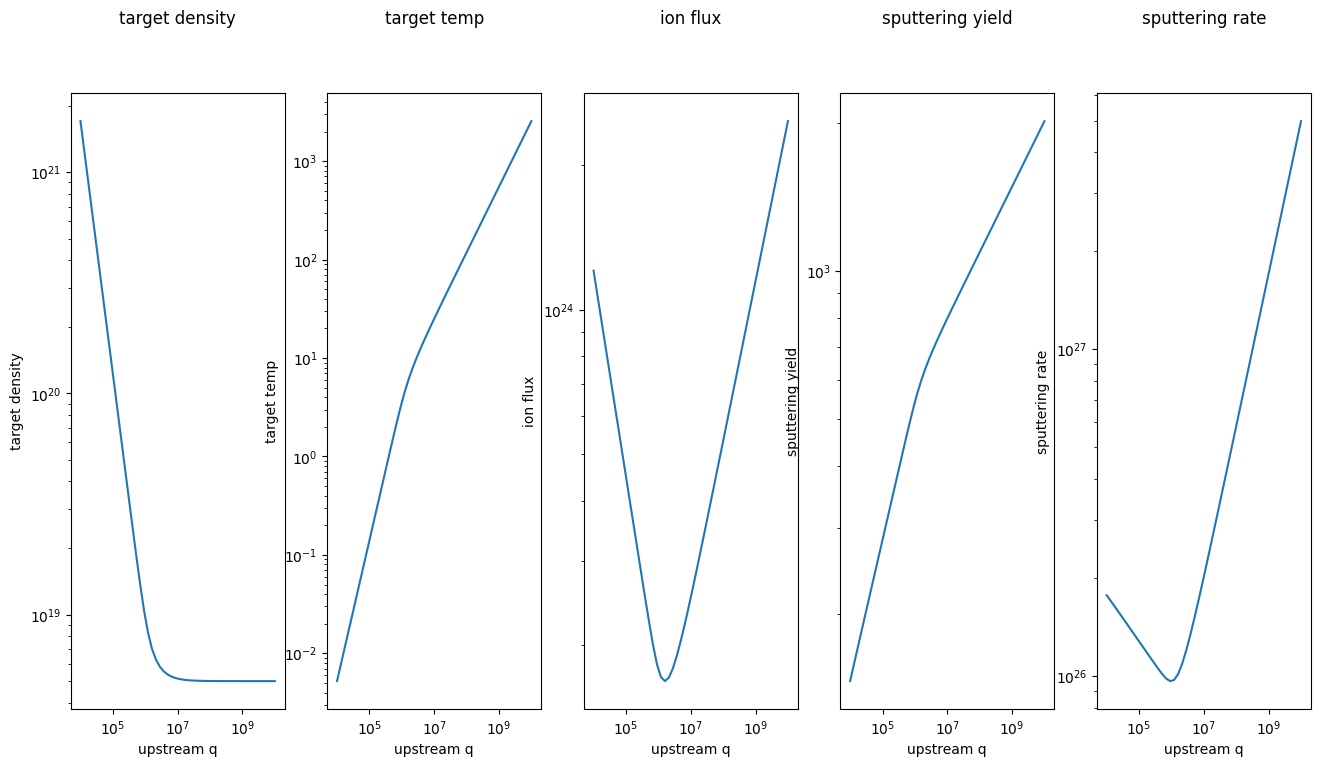

In [102]:

fig, axs = plt.subplots(1, 5, figsize=(16, 8))

axs = axs
x_quantity = "upstream q"  # "upstream q"
y_quantity = ("target density", "target temp", "ion flux", "sputtering yield", "sputtering rate")
for i, y in enumerate(y_quantity):
    axs[i].set_title(y, pad=50)
    axs[i].plot(df_simple_model_train[x_quantity],
                df_simple_model_train[y],)
    # tu_im = axs[0].scatter(df_simple_model_train["upstream q"],
    #                         df_simple_model_train["upstream density"],
    #                         c = df_simple_model_train["sputtering rate"],
    #                         # s = 100.* df_simple_model_train["f mom"],
    #                         norm=LogNorm())
    # min_arg = df_simple_model_train["sputtering rate"].argmin()
    # axs[0].scatter(df_simple_model_train["upstream temperature"][min_arg], 
    #                df_simple_model_train["upstream density"][min_arg],
    #                c='r', marker='*', alpha=0.5
    # )


    axs[i].set_ylabel(y)
    axs[i].set_xlabel(x_quantity)

    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
# plt.colorbar(tu_im, ax=axs[0], orientation="horizontal", location="top")

plt.show()

In [106]:
upstream_q_range = (1.e7, 1.e7)
upstream_density_range = (1.e17, 1.e20)
f_mom_range = (0.999, 1.)  #(1.e-3, 1.)
connection_length_range = (5000., 5000.)  #(1.e-1, 1.e2)  #(1.e-3, 1.)
# upstream_density_range = (1.e-3, 1.)
num = 50
q_u = log_space(*upstream_q_range, num)[::-1]
n_u = log_space(*upstream_density_range, num)
f_mom = random_log_space(*f_mom_range, num)
connection_length = log_space(*connection_length_range, num)
nt, tt, ion_flux, sputtering, sputtering_yield = np.array([(NonLinearTwoPointModel2(upstream_q=q_u[i],
                                    #  f_mom=f_mom[i],
                                    parallel_connection_length=connection_length[i],
                                    f_mom=1.,  #0.9,
                                    f_c=1.,   #0.9,
                                    f_power=0.,
                                     upstream_density=n_u[i])()) for i in range(num)]).T

print(sputtering.shape)

df_simple_model_train = pd.DataFrame(
    {"upstream q": q_u,
     "upstream density":     n_u,
     "connection length":     connection_length,
    #  "f mom":                f_mom,
     "target density":      nt,
     "target temp":      tt,
     "ion flux":      ion_flux,
     "sputtering rate":      sputtering,
     "sputtering yield": sputtering_yield
     }
)
# Remove rows where there is no sputtering
# df_train = df_train[df_train['sputtering rate'] != 0.]
# df_test = df_test[df_test['sputtering rate'] != 0.]

display(df_simple_model_train)

(50,)


/var/folders/dn/cm037cfs6x91lt40wn_cx_6c0000gn/T/ipykernel_7283/1985813559.py:104: RuntimeWarning: invalid value encountered in power
  a = (f_m * self.n_u * t_t )** (7/2)
/var/folders/dn/cm037cfs6x91lt40wn_cx_6c0000gn/T/ipykernel_7283/1985813559.py:93: RuntimeWarning: invalid value encountered in power
  return (target_temperature ** (7/2) + 7 * self.L * self.f_c * self.q_u / (2. * self.kappa)) ** (2/7)
/var/folders/dn/cm037cfs6x91lt40wn_cx_6c0000gn/T/ipykernel_7283/1985813559.py:54: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(convert_eV_to_J(t_t)/ ION_MASS)
/var/folders/dn/cm037cfs6x91lt40wn_cx_6c0000gn/T/ipykernel_7283/1985813559.py:110: RuntimeWarning: invalid value encountered in sqrt
  c = ((np.sqrt(ION_MASS / (ELECTRIC_CHARGE * t_t)) * 2 * self.q_u * (1. - self.f_p)/ (ELECTRIC_CHARGE * self.gamma)) - (2. * e * (1. - self.f_p)) / (ELECTRIC_CHARGE* self.calc_ion_sound_speed(t_t) *self.gamma)) ** (7/2)
/var/folders/dn/cm037cfs6x91lt40wn_cx_6c0000gn/T/ipykerne

,upstream q,upstream density,connection length,target density,target temp,ion flux,sputtering rate,sputtering yield
0,10000000.0,1.000000e+17,5000.0,5.000001e+16,706.338592,1.301588e+22,2.030137e+25,1559.738762
1,10000000.0,1.151395e+17,5000.0,5.756979e+16,642.802810,1.429652e+22,2.188242e+25,1530.611000
2,10000000.0,1.325711e+17,5000.0,6.628560e+16,584.957667,1.570285e+22,2.358590e+25,1502.014631
3,10000000.0,1.526418e+17,5000.0,7.632095e+16,532.292250,1.724709e+22,2.542114e+25,1473.938295
4,10000000.0,1.757511e+17,5000.0,8.787561e+16,484.341446,1.894267e+22,2.739812e+25,1446.370646
5,10000000.0,2.023590e+17,5000.0,1.011796e+17,440.681833,2.080427e+22,2.952751e+25,1419.300318
6,10000000.0,2.329952e+17,5000.0,1.164978e+17,400.927934,2.284798e+22,3.182074e+25,1392.715894
7,10000000.0,2.682696e+17,5000.0,1.341351e+17,364.728809,2.509137e+22,3.429002e+25,1366.605865
8,10000000.0,3.088844e+17,5000.0,1.544427e+17,331.764954,2.755368e+22,3.694834e+25,1340.958587
9,10000000.0,3.556480e+17,5000.0,1.778248e+17,301.745476,3.025588e+22,3.980954e+25,1315.762229


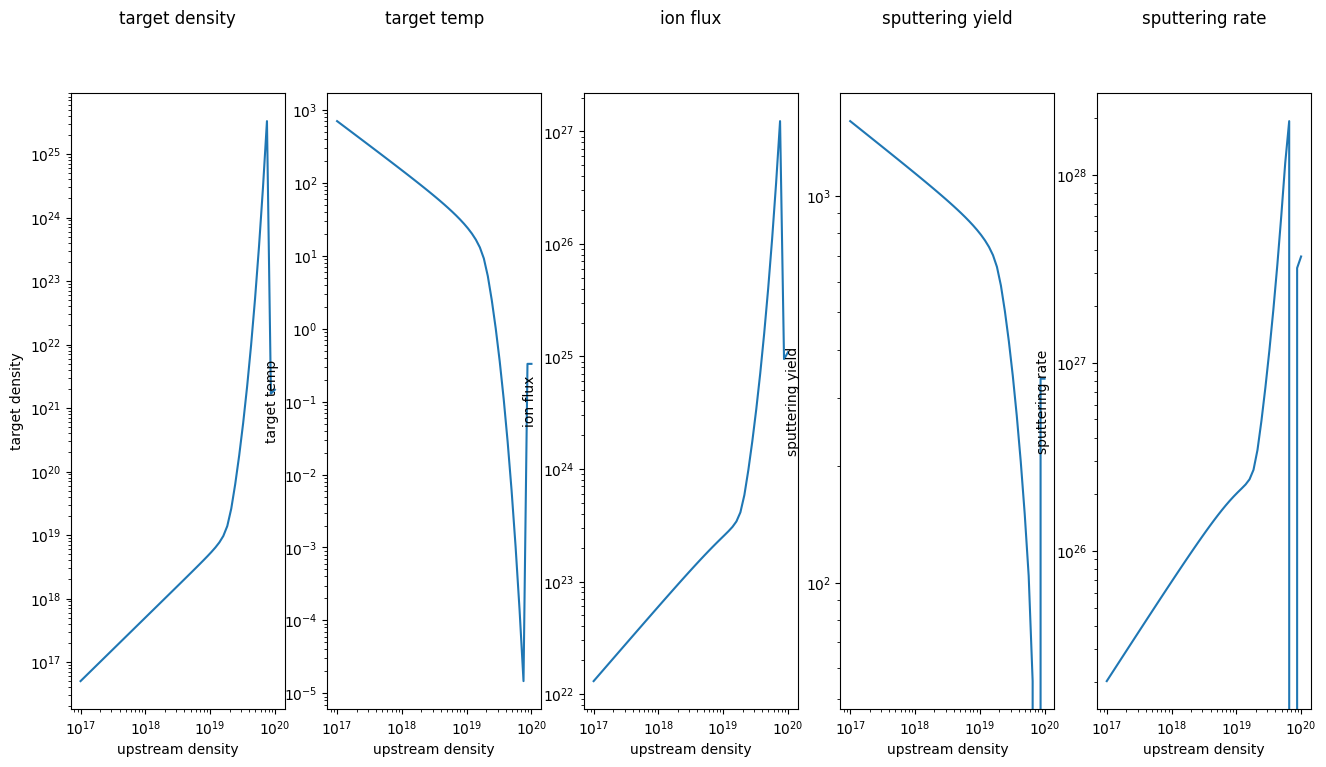

In [107]:
fig, axs = plt.subplots(1, 5, figsize=(16, 8))

axs = axs
x_quantity = "upstream density"  # "upstream q"
y_quantity = ("target density", "target temp", "ion flux", "sputtering yield", "sputtering rate")
for i, y in enumerate(y_quantity):
    axs[i].set_title(y, pad=50)
    axs[i].plot(df_simple_model_train[x_quantity],
                df_simple_model_train[y],)
    # tu_im = axs[0].scatter(df_simple_model_train["upstream q"],
    #                         df_simple_model_train["upstream density"],
    #                         c = df_simple_model_train["sputtering rate"],
    #                         # s = 100.* df_simple_model_train["f mom"],
    #                         norm=LogNorm())
    # min_arg = df_simple_model_train["sputtering rate"].argmin()
    # axs[0].scatter(df_simple_model_train["upstream temperature"][min_arg], 
    #                df_simple_model_train["upstream density"][min_arg],
    #                c='r', marker='*', alpha=0.5
    # )


    axs[i].set_ylabel(y)
    axs[i].set_xlabel(x_quantity)

    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
# plt.colorbar(tu_im, ax=axs[0], orientation="horizontal", location="top")

plt.show()

In [105]:
upstream_q_range = (1.e5, 1.e8)
upstream_density_range = (1.e17, 1.e20)
f_mom_range = (0.999, 1.)  #(1.e-3, 1.)
connection_length_range = (1000., 1000.)
num = 500
q_u = random_log_space(*upstream_q_range, num)
n_u = random_log_space(*upstream_density_range, num)
# f_mom = random_log_space(*f_mom_range, num)
connection_length = random_log_space(*connection_length_range, num)
nt, tt, ion_flux, sputtering, sputtering_yield = np.array([(NonLinearTwoPointModel2(upstream_q=q_u[i],
                                    #  f_mom=f_mom[i],
                                    f_c=1.,
                                    f_mom=1.,
                                    f_power=0.9,
                                    parallel_connection_length=connection_length[i],
                                     upstream_density=n_u[i])()) for i in range(num)]).T


df_simple_model_train = pd.DataFrame(
    {"upstream q": q_u,
     "upstream density":     n_u,
     "connection length":     connection_length,
    #  "f mom":                f_mom,
     "target density":      nt,
     "target temp":      tt,
     "ion flux":      ion_flux,
     "sputtering rate":      sputtering,
     "sputtering yield":      sputtering_yield,
     }
)
# Remove rows where there is no sputtering
# df_train = df_train[df_train['sputtering rate'] != 0.]
# df_test = df_test[df_test['sputtering rate'] != 0.]

display(df_simple_model_train)

/var/folders/dn/cm037cfs6x91lt40wn_cx_6c0000gn/T/ipykernel_7283/1985813559.py:104: RuntimeWarning: invalid value encountered in power
  a = (f_m * self.n_u * t_t )** (7/2)
/var/folders/dn/cm037cfs6x91lt40wn_cx_6c0000gn/T/ipykernel_7283/1985813559.py:93: RuntimeWarning: invalid value encountered in power
  return (target_temperature ** (7/2) + 7 * self.L * self.f_c * self.q_u / (2. * self.kappa)) ** (2/7)
/var/folders/dn/cm037cfs6x91lt40wn_cx_6c0000gn/T/ipykernel_7283/1985813559.py:54: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(convert_eV_to_J(t_t)/ ION_MASS)
/var/folders/dn/cm037cfs6x91lt40wn_cx_6c0000gn/T/ipykernel_7283/1985813559.py:110: RuntimeWarning: invalid value encountered in sqrt
  c = ((np.sqrt(ION_MASS / (ELECTRIC_CHARGE * t_t)) * 2 * self.q_u * (1. - self.f_p)/ (ELECTRIC_CHARGE * self.gamma)) - (2. * e * (1. - self.f_p)) / (ELECTRIC_CHARGE* self.calc_ion_sound_speed(t_t) *self.gamma)) ** (7/2)
/var/folders/dn/cm037cfs6x91lt40wn_cx_6c0000gn/T/ipykerne

,upstream q,upstream density,connection length,target density,target temp,ion flux,sputtering rate,sputtering yield
0,7.539007e+06,1.747950e+18,1000.0,8.740267e+17,84.164876,7.853931e+22,8.005021e+25,1019.237431
1,1.361226e+05,2.723698e+17,1000.0,1.362051e+17,20.580558,6.052278e+21,4.654351e+24,769.024714
2,1.955688e+07,2.844843e+19,1000.0,2.575073e+19,5.625895,5.982493e+23,3.549509e+26,593.316004
3,1.097218e+06,1.797369e+19,1000.0,3.043929e+19,1.275955,3.367823e+23,1.485111e+26,440.970548
4,2.622934e+07,5.250635e+17,1000.0,2.625319e+17,441.242224,5.401540e+22,7.668356e+25,1419.661104
...,...,...,...,...,...,...,...,...
495,1.754879e+06,7.457053e+17,1000.0,3.728724e+17,57.314681,2.764969e+22,2.609712e+25,943.848553
496,2.725449e+07,1.895285e+17,1000.0,9.476426e+16,898.429721,2.782170e+22,4.553336e+25,1636.613401
497,7.337943e+07,2.969270e+18,1000.0,1.484651e+18,262.623517,2.356613e+23,3.015811e+26,1279.723013
498,2.402529e+05,4.399564e+19,1000.0,2.312525e+23,0.000265,3.689399e+25,2.715575e+27,73.604807


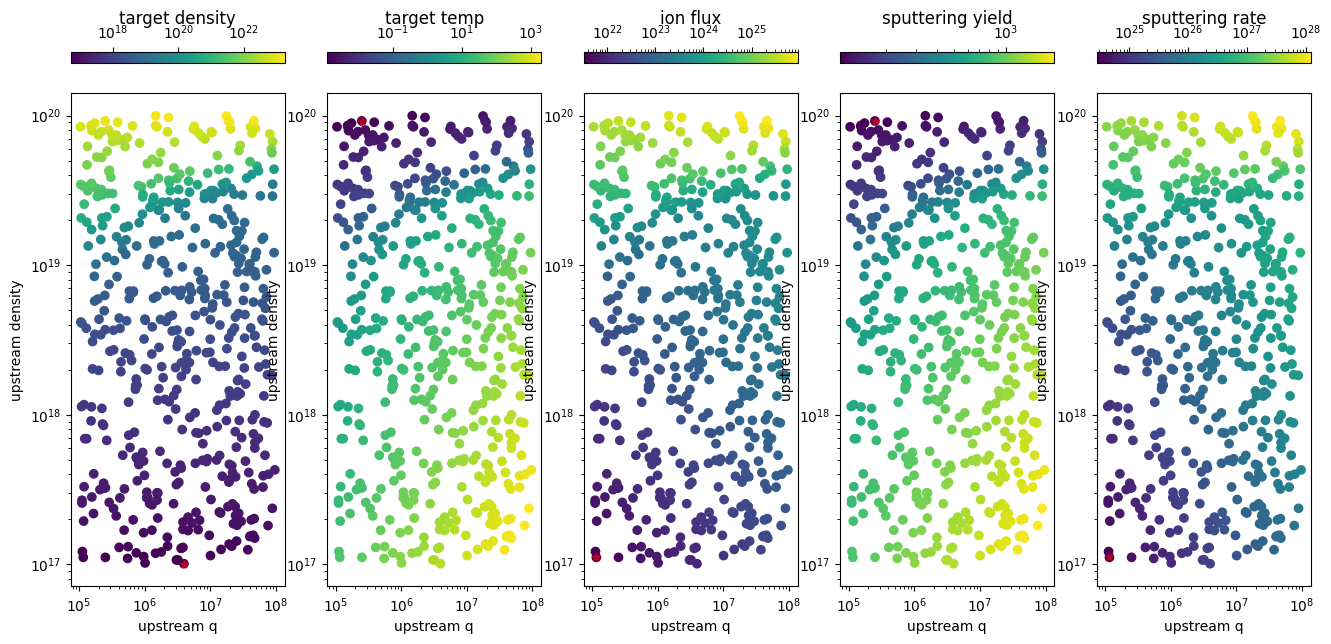

In [88]:

x0_quantity = "upstream q"
x1_quantity = "upstream density"
y_quantity = ("target density", "target temp", "ion flux", "sputtering yield", "sputtering rate")

fig, axs = plt.subplots(1, len(y_quantity), figsize=(16, 8))


for i, y in enumerate(y_quantity):
    axs[i].set_title(y, pad=50)
    # axs[i].plot(df_simple_model_train["upstream q"],
    #             df_simple_model_train[y],)
    tu_im = axs[i].scatter(df_simple_model_train[x0_quantity],
                            df_simple_model_train[x1_quantity],
                            c = df_simple_model_train[y],
                            # s = 100.* df_simple_model_train["f mom"],
                            norm=LogNorm())
    min_arg = df_simple_model_train[y].argmin()
    axs[i].scatter(df_simple_model_train[x0_quantity][min_arg], 
                   df_simple_model_train[x1_quantity][min_arg],
                   c='r', marker='*', alpha=0.5
    )
    # axs[i].scatter(df_simple_model_train["connection length"][min_arg], 
    #                df_simple_model_train["upstream q"][min_arg],
    #                c='r', marker='*', alpha=0.5
    # )
    plt.colorbar(tu_im, ax=axs[i], orientation="horizontal", location="top")


    axs[i].set_ylabel(x1_quantity)
    axs[i].set_xlabel(x0_quantity)

    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
# 

plt.show()

In [89]:
# Define the name of the dataset
simple_model_dataset_id = "Simple_Model_Data"

# Initialise a Dataset object
simple_model_dataset = tl.Dataset(id=simple_model_dataset_id)
simple_model_dataset.delete()
simple_model_emulator.delete()
# Upload the dataset to the cloud
simple_model_dataset.upload(df_simple_model_train)

Exception: Error Code: 404 - Dataset 'Simple_Model_Data' not found. Are you sure you provided the correct dataset ID?

In [ ]:
# Initialise emulator
simple_model_emulator_id = "Simple_Model_GP"

simple_model_emulator = tl.Emulator(id=simple_model_emulator_id)

# Train the emulator
simple_model_emulator.train(dataset=simple_model_dataset,
                    inputs=["upstream temperature", "upstream density"],
                    outputs=["sputtering rate"],
                      verbose=True)

We have now trained a surrogate model for our simple 2 point model.

This surrogate model can be called with an upstream temperature and an upstream density and predict the sputtering yield.

In [ ]:
# Make many input data points
nmesh = 20
ts = log_space(*upstream_temperature_range, nmesh)
ns = log_space(*upstream_density_range, nmesh+1)
tt, nn = np.meshgrid(ts, ns, indexing='ij')


df_simple_model_full = pd.DataFrame(
    {"upstream temperature": tt.flatten(),
     "upstream density":     nn.flatten(),
     }
)

In [ ]:
# Predictions on full data
simple_model_predictions = simple_model_emulator.predict(df_simple_model_full[["upstream temperature", "upstream density"]])
simple_model_predictions_df = pd.concat([simple_model_predictions[0], simple_model_predictions[1]], axis=1)
simple_model_mean, simple_model_stdev = simple_model_predictions_df.iloc[:, 0].values, simple_model_predictions_df.iloc[:, 1].values

We have now made many predictions covering the full parameter space using our surrogate model!

Let's plot these predictions alongside the uncertainty

In [ ]:
ss = simple_model_mean.reshape((len(ts), len(ns)))
ee = simple_model_stdev.reshape((len(ts), len(ns)))

fig, axs = plt.subplots(1, 2)
axs[0].set_title("Sputtering Rate", pad=50)
axs[1].set_title("Model Uncertainty", pad=50)

tu_cf = axs[0].contourf(
            tt,
            nn,
            ss,
            cmap=cmap,
            levels=20,
            # alpha=alpha_fn,
            # vmin=vmin,
            # vmax=vmax,
        )
tu_im = axs[0].scatter(df_simple_model_train["upstream temperature"], df_simple_model_train["upstream density"], c = df_simple_model_train["sputtering rate"], cmap=cmap)
axs[0].scatter(df_simple_model_train["upstream temperature"], df_simple_model_train["upstream density"], marker='x', c='k')
tu_cf = axs[1].contourf(
            tt,
            nn,
            ee,
            cmap=uncert_cmap,
            levels=20,
            # alpha=alpha_fn,
            # vmin=vmin,
            # vmax=vmax,
        )

for ax in axs:
    ax.set_xlabel("Upstream Temperature (eV)")
    ax.set_ylabel("Upstream Density (m$^{-3}$)")
    ax.set_xscale('log')
    ax.set_yscale('log')
axs[1].yaxis.tick_right()  # Move ticks to the right
axs[1].yaxis.set_label_position("right")  # Move label to the right
axs[1].spines['right'].set_position(('outward', 0))  # Make the right spine visible
plt.colorbar(tu_im, ax=axs[0], orientation="horizontal", location="top")
plt.colorbar(tu_cf, ax=axs[1], orientation="horizontal", location="top")

plt.show()

Our uncertainty is huge!

We need to sample from our full model more if we are to improve the validity of our surrogate model.

Now we want to suggest some new regions of parameter space to sample. We hope that these suggestions will improve the uncertainty of our surrogate model

In [ ]:

df_suggested_next_sample, _ = simple_model_emulator.recommend(num_points=5,
                                        acq_func="explore"
                                        # acq_func="ExpectedImprovement"
                                        )

Let's evaluate our model at this point

In [ ]:

new_t_u, new_n_u = df_suggested_next_sample["upstream temperature"], df_suggested_next_sample["upstream density"] 
new_sputtering = NonLinearTwoPointModel(upstream_temperature=new_t_u, upstream_density=new_n_u)()

df_new_train = pd.DataFrame(
    {"upstream temperature": new_t_u,
     "upstream density":     new_n_u,
     "sputtering rate":      new_sputtering
     }
)
df_simple_model_improved_train = pd.concat([df_simple_model_train, df_new_train], ignore_index=True)

# Initialise a Dataset object
simple_model_improved_dataset.delete()
simple_model_improved_emulator.delete()
simple_model_improved_dataset = tl.Dataset(id="Simple Model Improved Dataset")

# Upload the dataset to the cloud
simple_model_improved_dataset.upload(df_simple_model_improved_train)

# Initialise emulator
simple_model_improved_emulator = tl.Emulator(id="Simple Model Improved")
# Train the emulator
simple_model_improved_emulator.train(dataset=simple_model_improved_dataset,
                    inputs=["upstream temperature", "upstream density"],
                    outputs=["sputtering rate"],
                      verbose=True)


Let's make our predictions with this improved model

In [ ]:

# Predictions on full data
simple_model_improved_predictions = simple_model_improved_emulator.predict(df_simple_model_full[["upstream temperature", "upstream density"]])
simple_model_improved_predictions_df = pd.concat([simple_model_improved_predictions[0], simple_model_improved_predictions[1]], axis=1)
simple_model_improved_mean, simple_model_improved_stdev = simple_model_improved_predictions_df.iloc[:, 0].values, simple_model_improved_predictions_df.iloc[:, 1].values

In [ ]:

ss = simple_model_improved_mean.reshape((len(ts), len(ns)))
ee = simple_model_improved_stdev.reshape((len(ts), len(ns)))


fig, axs = plt.subplots(1, 2)
axs[0].set_title("Sputtering Rate", pad=50)
axs[1].set_title("Model Uncertainty", pad=50)
# tu_im = axs[0].scatter(np.exp(df_train["upstream temperature"]), np.exp(df_train["upstream density"]), c = np.exp(df_train["sputtering rate"]))
tu_cf = axs[0].contourf(
            tt,
            nn,
            ss,
            cmap=cmap,
            levels=levels,
            # alpha=alpha_fn,
            # vmin=vmin,
            # vmax=vmax,
        )
tu_im = axs[0].scatter(df_simple_model_train["upstream temperature"], df_simple_model_train["upstream density"], c = df_simple_model_train["sputtering rate"], cmap=cmap)
axs[0].scatter(df_simple_model_train["upstream temperature"], df_simple_model_train["upstream density"], marker='x', c='k')
axs[0].scatter(new_t_u, new_n_u, marker='^', c='k')
tu_cf = axs[1].contourf(
            tt,
            nn,
            ee,
            cmap=uncert_cmap,
            levels=20,
            # alpha=alpha_fn,
            # vmin=vmin,
            # vmax=vmax,
        )

for ax in axs:
    ax.set_xlabel("Upstream Temperature (eV)")
    ax.set_ylabel("Upstream Density (m$^{-3}$)")
    ax.set_xscale('log')
    ax.set_yscale('log')
axs[1].yaxis.tick_right()  # Move ticks to the right
axs[1].yaxis.set_label_position("right")  # Move label to the right
axs[1].spines['right'].set_position(('outward', 0))  # Make the right spine visible
plt.colorbar(tu_im, ax=axs[0], orientation="horizontal", location="top")
plt.colorbar(tu_cf, ax=axs[1], orientation="horizontal", location="top")

plt.show()

Let's make another suggestion for improving our model

In [ ]:

df_max_new_improved, _ = simple_model_improved_emulator.recommend(num_points=1,
                                        acq_func="explore"
                                        # acq_func="ExpectedImprovement"
                                        )

In [ ]:

new_t_u, new_n_u = [5000, 2000.], [8.e19, 1.e19]
new_sputtering = NonLinearTwoPointModel(upstream_temperature=new_t_u, upstream_density=new_n_u)()

print(new_sputtering)

Finally, we will tidy up our folder

In [ ]:
# Delete emulator and dataset
# simple_model_emulator.delete()
simple_model_dataset.delete()
improved_emulator.delete()
improved_dataset.delete()

We can see there's a rough positive correlation between the two; as magnetic field increases, so does energy confinement time. However, they are not perfectly correlated and the relationship seems very unclear and messy. This is because there are more than 7 other important parameters changing across these experiments, so of course it's difficult to see a clear relationship when only 1 of the features is used for plotting.